In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import heapq
import seaborn as sns

from environment.environment import GridWorldMFG_MultiGroup
from trainer.amid_trainer import AMID_Trainer_MultiGroup
from solver.solver import PMFG_OMD_Solver_MultiGroup, solve_multigroup
from visualization.visualizationh import plot_heatmap, compute_exploitability_multigroup, plot_losses

In [2]:
import yaml
import os
from pathlib import Path

def load_config(config_path="config.yaml"):
    """Load configuration from YAML file."""
    # Get the directory where the notebook is located
    notebook_dir = Path(os.getcwd())
    config_file = notebook_dir / config_path
    
    with open(config_file, 'r') as f:
        config = yaml.safe_load(f)
    return config

def create_multigroup_from_config(config):
    """Create environment, solvers, and trainer from config."""
    device = config.get("device", "cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")
    
    # Extract grid config
    grid_cfg = config["grid"]
    rows, cols = grid_cfg["rows"], grid_cfg["cols"]
    
    # Convert groups to correct format (convert lists to tuples for coordinates)
    groups = []
    for g in config["groups"]:
        groups.append({
            "source": tuple(g["source"]),
            "sink": tuple(g["sink"]),
            "mass": g["mass"]
        })
    
    # Create environment
    env = GridWorldMFG_MultiGroup(
        rows=rows, cols=cols,
        groups=groups,
        obstacles=grid_cfg.get("obstacles", []),
        device=device
    )
    
    # Create solvers
    solver_cfg = config["solver"]
    solvers = [
        PMFG_OMD_Solver_MultiGroup(
            env, group_idx=k,
            eta=solver_cfg["eta"],
            tau=solver_cfg["tau"],
            T=solver_cfg["T"],
            alpha=solver_cfg["alpha"],
            H=solver_cfg["H"]
        )
        for k in range(env.K)
    ]
    
    # Create trainer
    trainer_cfg = config["trainer"]
    trainer = AMID_Trainer_MultiGroup(env, solvers, leader_lr=trainer_cfg["leader_lr"])
    
    return env, solvers, trainer, config


In [ ]:
# ─────────────────────────────────────────────────────────────
# 8.  MAIN  — Multi-group from YAML config
# ─────────────────────────────────────────────────────────────

def run_amid_multigroup(config_path="config.yaml"):
    """
    Run AMID training using configuration from YAML file.
    
    Args:
        config_path: Path to YAML config file (relative to notebook directory)
    """
    # Load configuration
    config = load_config(config_path)
    
    # Create environment, solvers, and trainer from config
    env, solvers, trainer, cfg = create_multigroup_from_config(config)
    
    print(env.dist_maps)  # Print distance map for group 0 as a sanity check
    print(trainer.base_thetas)  # Print base theta for group 0 as a sanity check

    # Extract parameters
    num_epochs = cfg["trainer"]["num_epochs"]
    
    # Training loop
    losses = []
    print("\nEpoch | Loss")
    print("-" * 25)
    for epoch in range(num_epochs):
        loss = trainer.train_step()
        losses.append(loss)
        if epoch % 1 == 0:
            print(f"{epoch:5d} | {loss:.6f}")
        

    # ── Final evaluation ─────────────────────────────────────
    print("\n--- Final Evaluation ---")
    with torch.no_grad():
        inp    = trainer._prepare_input()
        theta1 = - trainer.leader_nets(inp)
        theta_list  = [trainer.base_thetas[k] + theta1 for k in range(env.K)]
        policies, flows, L_total = solve_multigroup(solvers, theta_list)

    exp = compute_exploitability_multigroup(
        solvers, policies, flows, theta_list
    )
    for k, v in exp.items():
        print(f"  Group {k} exploitability: {v:.6f}")

    plot_losses({"Total leader loss": losses})

    return L_total, losses, theta1, env.obstacles
    

if __name__ == "__main__":
    print("Running AMID Multi-Group Example...")
    

Running AMID Multi-Group Example...


Device: cpu
[[[  6.   5.   4.   3.   2.]
  [  5. 100.   3. 100.   1.]
  [  4.   3.   2.   1. -10.]]]
[tensor([[  -6.,   -5.,   -4.,   -3.,   -2.],
        [  -5., -100.,   -3., -100.,   -1.],
        [  -4.,   -3.,   -2.,   -1.,   10.]], dtype=torch.float64)]

Epoch | Loss
-------------------------
    0 | 4.710602
    1 | 5.154021

--- Final Evaluation ---
  Group 0 exploitability: 0.000001


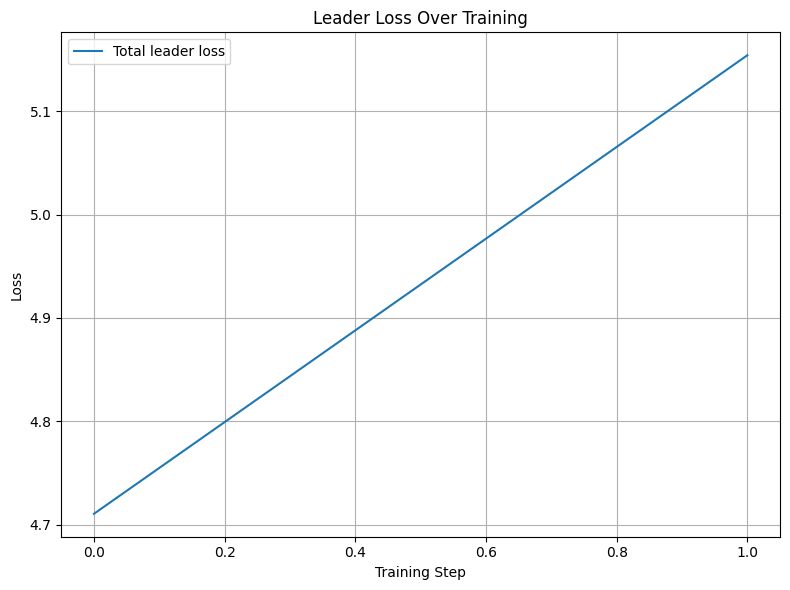

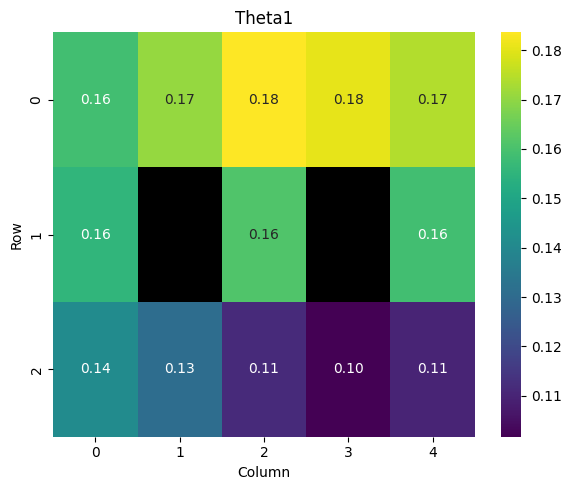

In [7]:
final_flow_4, losses_4, theta1_4, obstacles_4 = run_amid_multigroup(config_path="config_braess.yaml")

plot_heatmap(theta1_4[0].cpu().detach().numpy(), mask = obstacles_4.cpu().detach().numpy(), title="Theta1", xlabel="Column", ylabel="Row")

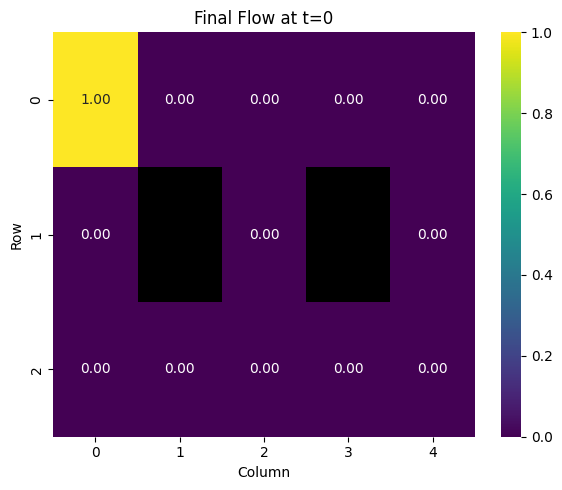

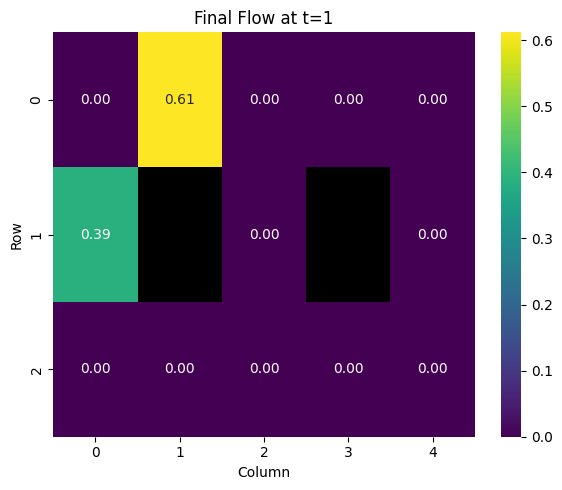

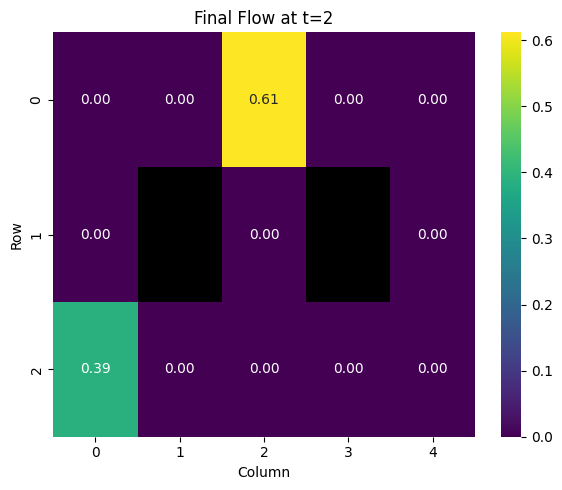

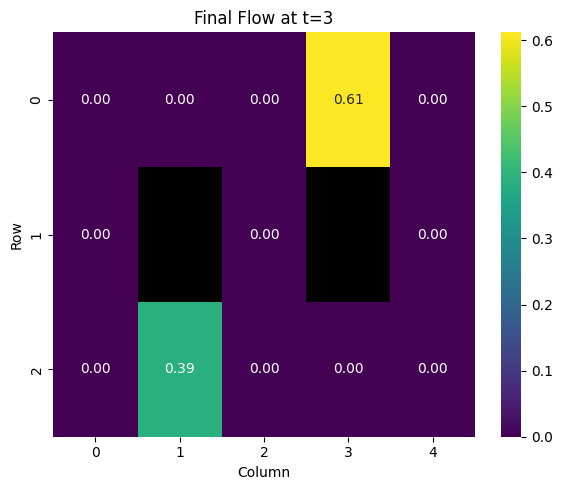

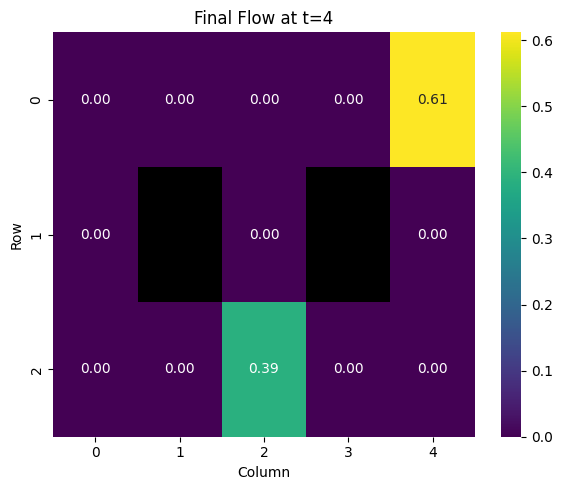

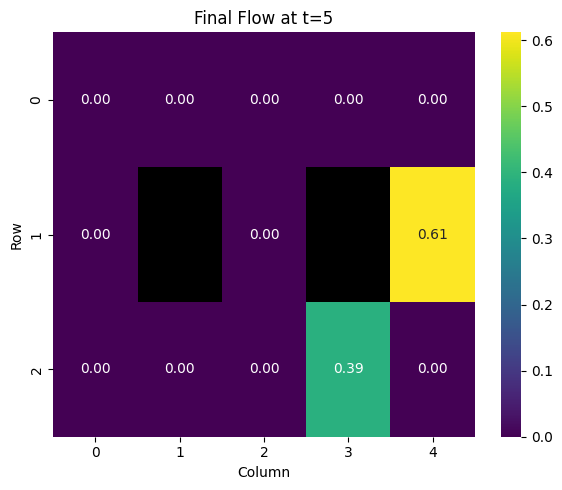

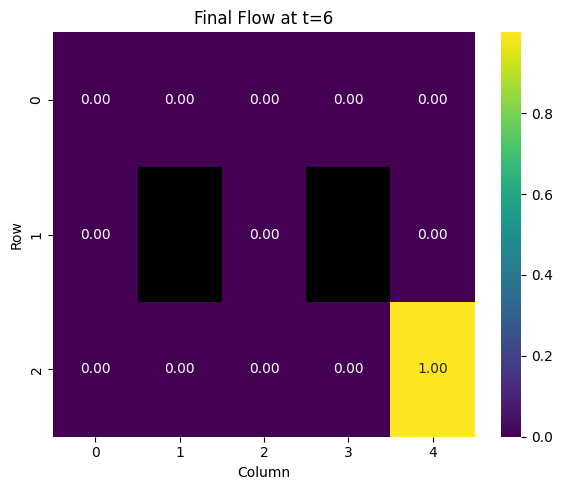

In [8]:
for i in range(final_flow_4.shape[0]):
    plot_heatmap(final_flow_4[i].cpu().detach().numpy(), mask=obstacles_4.cpu().detach().numpy(), title=f"Final Flow at t={i}", xlabel="Column", ylabel="Row")